# Lab: Content based Recommender Systems

## Section 1: Data Preparation

Two most ubiquitous types of personalized recommender systems are **Content-Based** and **Collaborative Filtering**. Collaborative filtering produces recommendations based on the knowledge of users’ attitude to items, that it uses the “wisdom of the crowd” to recommend items.

In contrast, content-based recommender systems focus on the attributes of the items and give you recommendations based on the similarity between them.

In this lab, we will focus on content-based recommender systems.

### The MovieLens Dataset

[MovieLens](https://grouplens.org/datasets/movielens/) is one of the most popular (publicly) available datasets for benchmarking. In this notebook, we will work with the [1M](https://grouplens.org/datasets/movielens/1m/) version, which contains 1,000,209 anonymous ratings of approximately 3,900 movies made by 6,040 MovieLens users who joined MovieLens in 2000.

Let's load this data with pandas

In [1]:
from urllib.request import urlretrieve
import zipfile, os

In [2]:
# If file exists, skip the download
data_file_path = "movielens/Movielens1M/"
data_file_name = data_file_path + "movielens_1m.zip"

# If directory does not exist, create
if not os.path.exists(data_file_path):
    os.makedirs(data_file_path)

if not os.path.exists(data_file_name):
    urlretrieve("https://files.grouplens.org/datasets/movielens/ml-1m.zip", data_file_name)

In [3]:
# unzip and read the *.dat files
dataFile = zipfile.ZipFile(data_file_path + "movielens_1m.zip")

ratings_path = dataFile.extract("ml-1m/ratings.dat", path=data_file_path)
users_path = dataFile.extract("ml-1m/users.dat", path=data_file_path)
movies_path = dataFile.extract("ml-1m/movies.dat", path=data_file_path)

### Data Preprocessing

The original data are contained in three files: movies.dat, ratings.dat, and users.dat. To make it easier to work with the data, we convert them into csv files.

In [4]:
import pandas as pd

In [5]:
# Define file directories
MOVIELENS_DIR = 'dat'
USER_DATA_FILE = 'users.dat'
MOVIE_DATA_FILE = 'movies.dat'
RATING_DATA_FILE = 'ratings.dat'

In [6]:
# Specify User's Age and Occupation Column
AGES = { 1: "Under 18", 18: "18-24", 25: "25-34", 35: "35-44", 45: "45-49", 50: "50-55", 56: "56+" }
OCCUPATIONS = { 0: "other", 1: "academic/educator", 2: "artist", 3: "clerical/admin",
4: "college/grad student", 5: "customer service", 6: "doctor/health care",
7: "executive/managerial", 8: "farmer", 9: "homemaker", 10: "K-12 student", 11: "lawyer", 12: "programmer",
13: "retired", 14: "sales/marketing", 15: "scientist", 16: "self-employed", 17: "technician/engineer", 18: "tradesman/craftsman", 19: "unemployed", 20: "writer" }

In [7]:
# Define csv files to be saved into
USERS_CSV_FILE = 'users.csv'
MOVIES_CSV_FILE = 'movies.csv'
RATINGS_CSV_FILE = 'ratings.csv'

In [8]:
# Read the ratings file
ratings = pd.read_csv(ratings_path, sep='::',
                      engine='python', encoding='latin-1',
                      names=['user_id', 'movie_id', 'rating', 'timestamp'])

# Set max_userid to the maximum user_id in the ratings
max_userid = ratings['user_id'].drop_duplicates().max()

# Set max_movieid to the maximum movie_id in the ratings
max_movieid = ratings['movie_id'].drop_duplicates().max()

# Add user_emb_id column whose values == user_id - 1
ratings['user_emb_id'] = ratings['user_id'] - 1

# Add movie_emb_id column whose values == movie_id - 1
ratings['movie_emb_id'] = ratings['movie_id'] - 1

print(len(ratings)), 'ratings loaded'

1000209


(None, 'ratings loaded')

In [9]:
# Save into ratings.csv
ratings.to_csv(RATINGS_CSV_FILE,
               sep='\t',
               header=True,
               encoding='latin-1',
               columns=['user_id', 'movie_id', 'rating', 'timestamp', 'user_emb_id', 'movie_emb_id'])
print('Saved to', RATINGS_CSV_FILE)

Saved to ratings.csv


In [10]:
# Read the users file
users = pd.read_csv(users_path,
                    sep='::',
                    engine='python',
                    encoding='latin-1',
                    names=['user_id', 'gender', 'age', 'occupation', 'zipcode'])

users['age_desc'] = users['age'].apply(lambda x: AGES[x])
users['occ_desc'] = users['occupation'].apply(lambda x: OCCUPATIONS[x])
print(len(users), 'descriptions of', max_userid, 'users loaded.')

6040 descriptions of 6040 users loaded.


In [11]:
# Save into users.csv
users.to_csv(USERS_CSV_FILE,
             sep='\t',
             header=True,
             encoding='latin-1',
             columns=['user_id', 'gender', 'age', 'occupation', 'zipcode', 'age_desc', 'occ_desc'])

print('Saved to', USERS_CSV_FILE)

Saved to users.csv


In [12]:
# Read the movies file
movies = pd.read_csv(movies_path,
                     sep='::',
                     engine='python',
                     encoding='latin-1',
                     names=['movie_id', 'title', 'genres'])

print(len(movies), 'descriptions of', max_movieid, 'movies loaded.')

3883 descriptions of 3952 movies loaded.


In [13]:
# Save into movies.csv
movies.to_csv(MOVIES_CSV_FILE,
              sep='\t',
              header=True,
              columns=['movie_id', 'title', 'genres'])

print('Saved to', MOVIES_CSV_FILE)

Saved to movies.csv


## Section 2: Data Exploration - part 1

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [15]:
# Reading ratings file
ratings = pd.read_csv('ratings.csv', sep='\t', encoding='latin-1', usecols=['user_id', 'movie_id', 'rating', 'timestamp'])

# Reading users file
users = pd.read_csv('users.csv', sep='\t', encoding='latin-1', usecols=['user_id', 'gender', 'zipcode', 'age_desc', 'occ_desc'])

# Reading movies file
movies = pd.read_csv('movies.csv', sep='\t', encoding='latin-1', usecols=['movie_id', 'title', 'genres'])

### Check ratings

In [16]:
# Check the top 5 rows
print(ratings.head())

   user_id  movie_id  rating  timestamp
0        1      1193       5  978300760
1        1       661       3  978302109
2        1       914       3  978301968
3        1      3408       4  978300275
4        1      2355       5  978824291


In [17]:
# Check the file info
print(ratings.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 4 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   user_id    1000209 non-null  int64
 1   movie_id   1000209 non-null  int64
 2   rating     1000209 non-null  int64
 3   timestamp  1000209 non-null  int64
dtypes: int64(4)
memory usage: 30.5 MB
None


This confirms that there are 1M ratings for different user and movie combinations.

### Check users

In [18]:
# Check the top 5 rows
print(users.head())

   user_id gender zipcode  age_desc              occ_desc
0        1      F   48067  Under 18          K-12 student
1        2      M   70072       56+         self-employed
2        3      M   55117     25-34             scientist
3        4      M   02460     45-49  executive/managerial
4        5      M   55455     25-34                writer


In [19]:
# Check the file info
print(users.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6040 entries, 0 to 6039
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   user_id   6040 non-null   int64 
 1   gender    6040 non-null   object
 2   zipcode   6040 non-null   object
 3   age_desc  6040 non-null   object
 4   occ_desc  6040 non-null   object
dtypes: int64(1), object(4)
memory usage: 236.1+ KB
None


This confirms that there are 6040 users and we have 5 features for each (unique user ID, gender, age, occupation and the zip code they are living in).

### Check items (i.e., movies)

In [20]:
# Check the top 5 rows
print(movies.head())

   movie_id                               title                        genres
0         1                    Toy Story (1995)   Animation|Children's|Comedy
1         2                      Jumanji (1995)  Adventure|Children's|Fantasy
2         3             Grumpier Old Men (1995)                Comedy|Romance
3         4            Waiting to Exhale (1995)                  Comedy|Drama
4         5  Father of the Bride Part II (1995)                        Comedy


In [21]:
# Check the file info
print(movies.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3883 entries, 0 to 3882
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   movie_id  3883 non-null   int64 
 1   title     3883 non-null   object
 2   genres    3883 non-null   object
dtypes: int64(1), object(2)
memory usage: 91.1+ KB
None


This dataset contains attributes of the 3883 movies. There are 3 columns including the movie ID, their titles, and their genres. Genres are pipe-separated and are selected from 18 genres (Action, Adventure, Animation, Children's, Comedy, Crime, Documentary, Drama, Fantasy, Film-Noir, Horror, Musical, Mystery, Romance, Sci-Fi, Thriller, War, Western).

### Explore Movie Tittles

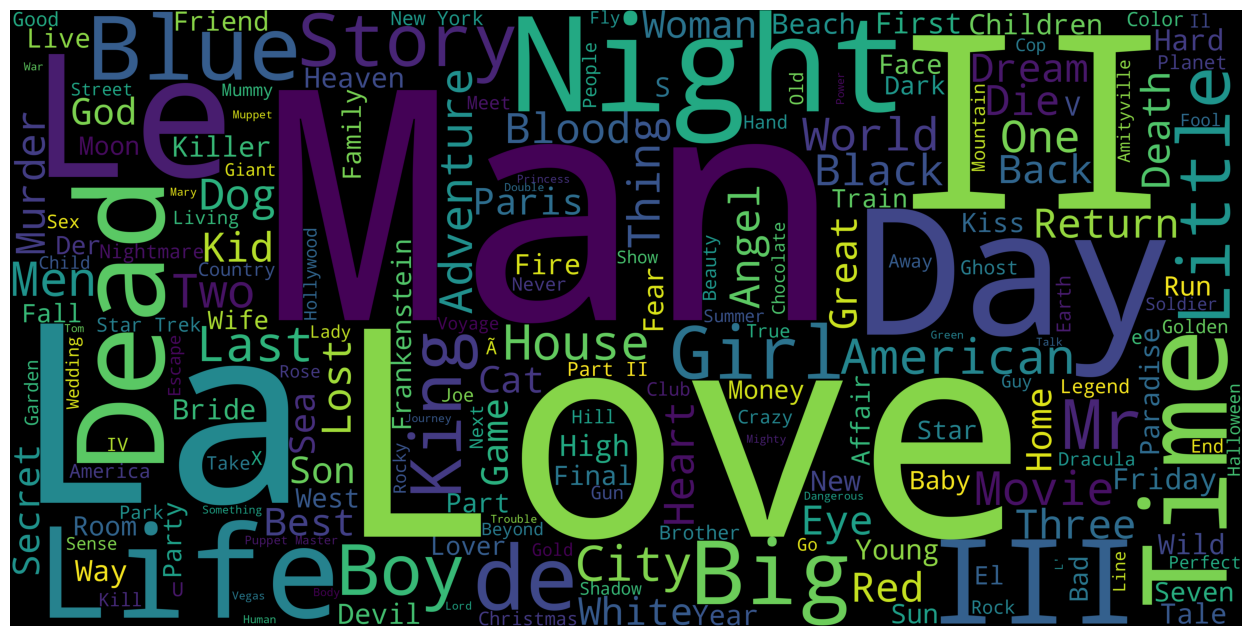

In [22]:
# Import new libraries
%matplotlib inline
import wordcloud
from wordcloud import WordCloud, STOPWORDS

# Create a wordcloud of the movie titles
movies['title'] = movies['title'].fillna("").astype('str')
title_corpus = ' '.join(movies['title'])
title_wordcloud = WordCloud(stopwords=STOPWORDS, background_color='black', height=2000, width=4000).generate(title_corpus)

# Plot the wordcloud
plt.figure(figsize=(16,8))
plt.imshow(title_wordcloud)
plt.axis('off')
plt.show()

## Section 3: Data Exploration - part 2

### Explore Ratings

Let's take a look at its summary statistics and distribution.

In [23]:
# Get summary statistics of rating

ratings['rating'].describe()

,rating
count,1.000209e+06
mean,3.581564e+00
std,1.117102e+00
min,1.000000e+00
25%,3.000000e+00
50%,4.000000e+00
75%,4.000000e+00
max,5.000000e+00


<ipython-input-24-e3c9e7783721>:8: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(ratings['rating'].fillna(ratings['rating'].median()))


<Axes: xlabel='rating', ylabel='Density'>

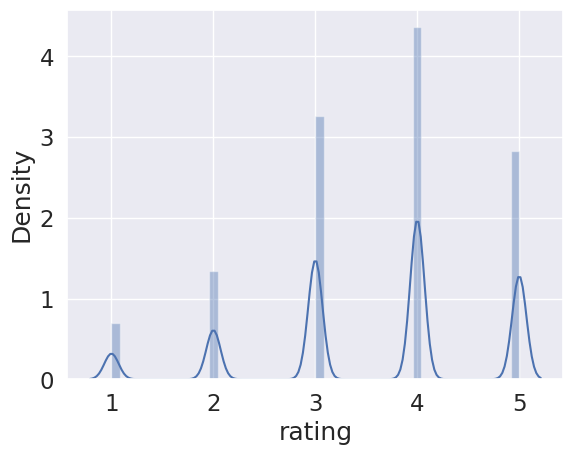

In [24]:
# Import seaborn library
import seaborn as sns
sns.set_style('whitegrid')
sns.set(font_scale=1.5)
%matplotlib inline

# Display distribution of rating
sns.distplot(ratings['rating'].fillna(ratings['rating'].median()))

It appears that users are quite generous in their ratings. The mean rating is 3.58 on a scale of 5. Half the movies have a rating of 4 and 5.

Let's also take a look at a subset of 20 movies with the highest rating.

In [25]:
# Join all 3 files into one dataframe
dataset = pd.merge(pd.merge(movies, ratings),users)

# Display 20 movies with highest ratings
dataset[['title','genres','rating']].sort_values('rating', ascending=False).head(20)

,title,genres,rating
0,Toy Story (1995),Animation|Children's|Comedy,5
657724,Rocky II (1979),Action|Drama,5
244214,Old Yeller (1957),Children's|Drama,5
657745,Rocky II (1979),Action|Drama,5
657752,Rocky II (1979),Action|Drama,5
657764,Rocky II (1979),Action|Drama,5
657773,Rocky II (1979),Action|Drama,5
244200,Old Yeller (1957),Children's|Drama,5
657789,Rocky II (1979),Action|Drama,5
657802,Rocky II (1979),Action|Drama,5


### Explore Genres

The genres variable will surely be important while building the recommendation engines since it describes the content of the film (i.e. Animation, Horror, Sci-Fi). A basic assumption is that films in the same genre should have similar contents. We will attempt to see exactly which genres are the most popular.

In [26]:
# Make a census of the genre keywords
genre_labels = set()
for s in movies['genres'].str.split('|').values:
    genre_labels = genre_labels.union(set(s))

# Function that counts the number of times each of the genre keywords appear
def count_word(dataset, ref_col, census):
    keyword_count = dict()

    for s in census:
        keyword_count[s] = 0

    for census_keywords in dataset[ref_col].str.split('|'):
        if type(census_keywords) == float and pd.isnull(census_keywords):
            continue

        for s in [s for s in census_keywords if s in census]:
            if pd.notnull(s):
                keyword_count[s] += 1
    #______________________________________________________________________
    # convert the dictionary in a list to sort the keywords by frequency
    keyword_occurences = []
    for k,v in keyword_count.items():
        keyword_occurences.append([k,v])
    keyword_occurences.sort(key=lambda x: x[1], reverse=True)
    return keyword_occurences, keyword_count

In [27]:
# Calling this function gives access to a list of genre keywords which are sorted by decreasing frequency
keyword_occurences, _ = count_word(movies, 'genres', genre_labels)
keyword_occurences[:5]

[['Drama', 1603],
 ['Comedy', 1200],
 ['Action', 503],
 ['Thriller', 492],
 ['Romance', 471]]

The top 5 genres are, in that respect order: Drama, Comedy, Action, Thriller, and Romance. I'll show this on a wordcloud too in order to make it more visually appealing.

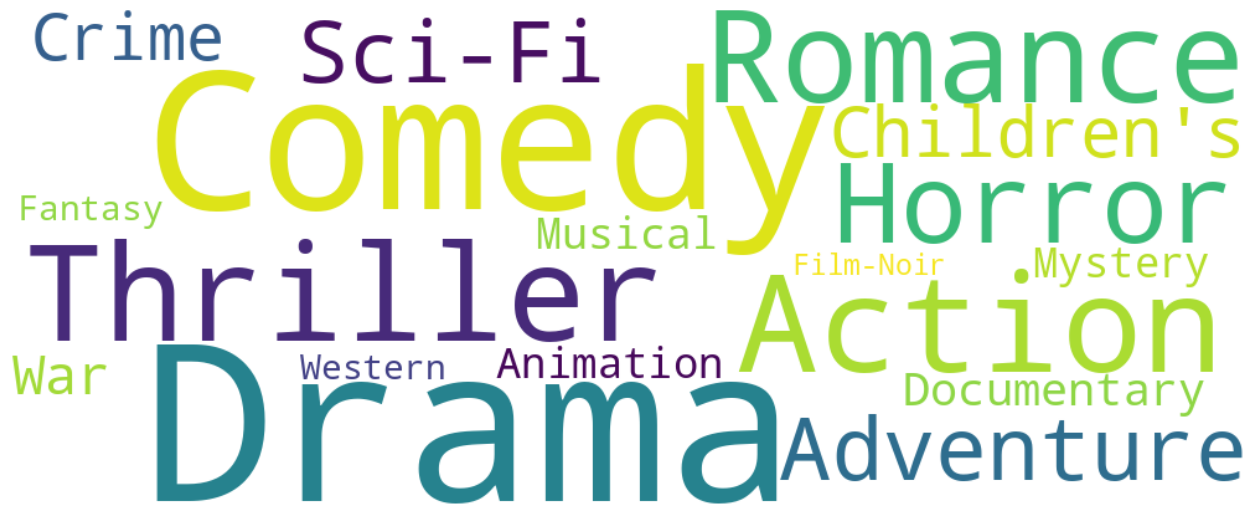

In [28]:
# Define the dictionary used to produce the genre wordcloud
genres = dict()
trunc_occurences = keyword_occurences[0:18]
for s in trunc_occurences:
    genres[s[0]] = s[1]

# Create the wordcloud
genre_wordcloud = WordCloud(width=1000,height=400, background_color='white')
genre_wordcloud.generate_from_frequencies(genres)

# Plot the wordcloud
f, ax = plt.subplots(figsize=(16, 8))
plt.imshow(genre_wordcloud, interpolation="bilinear")
plt.axis('off')
plt.show()

## Section 4: Let's build the Content-based Recommendation Model

The concepts of **Term Frequency (TF)** and **Inverse Document Frequency (IDF)** are used in information retrieval systems and also content based recommender systems. They are used to determine the relative importance of a document / article / news item / movie etc.

After calculating TF-IDF scores, how do we determine which items are closer to each other, rather closer to the user profile?

This is accomplished using the **Vector Space Model** which computes the proximity based on the angle between the vectors. In this model, each item is stored as a vector of its attributes (which are also vectors) in an **n-dimensional space** and the angles between the vectors are calculated to **determine the similarity between the vectors**.

(Remember we talked about ANN, VectorDB / LLMs in the lecture?)

The user profile vectors are also created based on his actions on previous attributes of items and the similarity between an item and a user is also determined in a similar way.

Now, we are going to build a Content-Based Recommendation Engine that computes similarity between movies based on movie genres.

It will suggest movies that are most similar to a particular movie based on its genre. To do so, we will make use of the file **movies.csv**.

In [29]:
# Break up the big genre string into a string array
movies['genres'] = movies['genres'].str.split('|')

# Convert genres to string value
movies['genres'] = movies['genres'].fillna("").astype('str')

We do not have a quantitative metric to judge our machine's performance so this will have to be done qualitatively. In order to do so, we will use **TfidfVectorizer** function from scikit-learn, which transforms text to feature vectors that can be used as input to estimator.

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer
tf = TfidfVectorizer(analyzer='word',ngram_range=(1, 2),min_df=1, stop_words='english')
tfidf_matrix = tf.fit_transform(movies['genres'])
tfidf_matrix.shape

(3883, 127)

We will be using the **[Cosine Similarity](https://masongallo.github.io/machine/learning,/python/2016/07/29/cosine-similarity.html)** to calculate a numeric quantity that denotes the similarity between two movies. Since we have used the TF-IDF Vectorizer, calculating the Dot Product will directly give us the Cosine Similarity Score. Therefore, we will use sklearn's **linear_kernel** instead of cosine_similarities since it is much faster.

In [31]:
from sklearn.metrics.pairwise import linear_kernel
cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)
cosine_sim[:4, :4]

array([[1.        , 0.14193614, 0.09010857, 0.1056164 ],
       [0.14193614, 1.        , 0.        , 0.        ],
       [0.09010857, 0.        , 1.        , 0.1719888 ],
       [0.1056164 , 0.        , 0.1719888 , 1.        ]])

We now have a pairwise cosine similarity matrix for all the movies in the dataset. The next step is to write a function that returns the 20 most similar movies based on the cosine similarity score.

In [32]:
# Build a 1-dimensional array with movie titles
titles = movies['title']
indices = pd.Series(movies.index, index=movies['title'])

# Function that get movie recommendations based on the cosine similarity score of movie genres
def genre_recommendations(title):
    idx = indices[title]
    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    sim_scores = sim_scores[1:21]
    movie_indices = [i[0] for i in sim_scores]
    return titles.iloc[movie_indices]

Let's try and get the top recommendations for a few movies and see how good the recommendations are.

In [33]:
genre_recommendations('Good Will Hunting (1997)').head(20)

,title
25,Othello (1995)
26,Now and Then (1995)
29,Shanghai Triad (Yao a yao yao dao waipo qiao) ...
30,Dangerous Minds (1995)
35,Dead Man Walking (1995)
39,"Cry, the Beloved Country (1995)"
42,Restoration (1995)
52,Lamerica (1994)
54,Georgia (1995)
56,Home for the Holidays (1995)


In [34]:
genre_recommendations('Toy Story (1995)').head(20)

,title
1050,Aladdin and the King of Thieves (1996)
2072,"American Tail, An (1986)"
2073,"American Tail: Fievel Goes West, An (1991)"
2285,"Rugrats Movie, The (1998)"
2286,"Bug's Life, A (1998)"
3045,Toy Story 2 (1999)
3542,Saludos Amigos (1943)
3682,Chicken Run (2000)
3685,"Adventures of Rocky and Bullwinkle, The (2000)"
236,"Goofy Movie, A (1995)"


In [35]:
genre_recommendations('Saving Private Ryan (1998)').head(20)

,title
461,Heaven & Earth (1993)
1204,Full Metal Jacket (1987)
1214,"Boat, The (Das Boot) (1981)"
1222,Glory (1989)
1545,G.I. Jane (1997)
1959,Saving Private Ryan (1998)
2358,"Thin Red Line, The (1998)"
2993,"Longest Day, The (1962)"
3559,Flying Tigers (1942)
3574,"Fighting Seabees, The (1944)"


As you can see, we have quite a decent list of recommendation for **Good Will Hunting** (Drama), **Toy Story** (Animation, Children's, Comedy), and **Saving Private Ryan** (Action, Thriller, War).

Pros:
* No need for data on other users, thus no cold-start or sparsity problems.
* Can recommend to users with unique tastes.
* Can recommend new & unpopular items.
* Can provide explanations for recommended items by listing content-features that caused an item to be recommended (in this case, movie genres)

Cons:
* Finding the appropriate features is hard.
* Does not recommend items outside a user's content profile.
* Unable to exploit quality judgments of other users.

# End of Lab!

References:

[1] MovieLens: https://github.com/khanhnamle1994/movielens